# MOBILE PRICE PREDICTION

# Import Libraries

In [2]:
!pip install -r requirements.txt

In [3]:
import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In the above section, the required libraries and settings were imported and configured to support data analysis, visualization, and statistical modeling for Mobile Price Prediction.
##### Core Libraries
    Numpy and Pandas: For numerical computations and data manipulation.
    Scipy Stats : To perform advance statistical test and analysis.
##### Statistical Analysis
    Variance_inflation_factor from statmodels: Helps detect multicollinearity among features.
##### Visualization Libraries
    Matplotlib and Seaborn: For creating static visualization with imporoved aesthetics.
##### Miscellaneous Settings
    Warnings Filtering : Suppressed warning using warning.filterwarnings to improved notebook readability.

# Machine Learning Library and Performance Metrices

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

##### Linear Models
    LinearRegression:A fundamental regression model for linear relationships.
    Ridge,Lasso,ElasticNet :Linear Model with different regularization techniques to prevent overfitting.
##### Data Splitting Model
    train_test_split:Ensure unbaised evalution by dividing the data into training and testing subsets.
##### Performance Metrics
    r2_score: Evaluates the proportions of variance explained by the model (higher value indicate better fit).
##### Preprocessing Tools
    StandardScaler : Normalies data by centering and sealing it.
    MinMaxScaler: Scales data to a fixed renage typically[0,1].

# Libraries Version

In [5]:
libraries = {
                "numpy":"np",
                "pandas":"pd",
                "scipy":"scipy",
                "statsmodels":"statsmodels",
                "seaborn":"sns",
                "sikit_learn":"sklearn"
           }

In [6]:
library_version ={}
for lib in libraries.keys():
    try:
        if lib == "sikit_learn":
            import sklearn
            library_version[lib]=sklearn.__version__
        else:
            module=__import__(lib)
        library_version[lib] =module.__version__
    except ModuleNotFoundError:
        library_version[lib]="Not Installed"
    except Exception as e:
        library_version[lib] = f"Error:{str(e)}"
    

In [7]:
from tabulate import tabulate

table = []
for lib, version in library_version.items():
    if version == "Not Installed":
        table.append([lib, f"Not installed. Install using 'pip install {lib}'"])
    else:
        table.append([lib, version])

print(tabulate(table, headers=["Library", "Version"], tablefmt="grid"))


+-------------+-----------+
| Library     | Version   |
+=============+===========+
| numpy       | 1.26.4    |
+-------------+-----------+
| pandas      | 2.2.2     |
+-------------+-----------+
| scipy       | 1.13.1    |
+-------------+-----------+
| statsmodels | 0.14.2    |
+-------------+-----------+
| seaborn     | 0.13.2    |
+-------------+-----------+
| sikit_learn | 0.13.2    |
+-------------+-----------+


This section is dedicated to verifying and recording the versions of the libraries used in the Mobile price prediction model.This ensure compatibility and help track the specific version fror reproducibility and troubleshooting.

# Loading Dataset

In [8]:
df = pd.read_csv("Cellphone.csv")

In this step, the dataset was loaded using **pandas.read_csv** into a DataFrame. This function is commonly used to import tabular data from a CSV file for further analysis.

**pd.read_csv("Cellphone.csv")**: Reads the dataset named **Cellphone.csv** and stores it in the DataFrame variable df. This dataset likely contains information related to various features and price that will be used to build the prediction model.

In [9]:
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


To gain an initial understanding of the dataset, the **`head()`** function was used on the DataFrame **`df`**. This function displays the first five rows of the dataset, providing an overview of the data structure and allowing a quick check for the following:

- **Column Names:** Identifying features in the dataset (e.g., Price, Sale, weight).
- **Data Types:** Ensuring correct data types (numerical, categorical) for each column.
- **Initial Data Inspection:** Checking for any obvious issues like missing or incorrectly formatted values.

The output of **`df.head()`** will help in determining how to proceed with further data preprocessing, such as handling missing values, performing encoding, or scaling features, depending on the content and structure observed.

In [10]:
df.tail()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.0,12.0,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.0,20.0,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9
160,1131,2536,9807,202.0,6.00,367,8,1.500,16.0,3.0,21.5,16.0,2700,8.4


To further understand the structure and completeness of the dataset, the **`tail()`** function was used on the DataFrame **`df`**. This function displays the last five rows of the dataset, offering several key insights:

- **End of Dataset:** Provides a view of the most recent data entries, which might be useful to detect any patterns, outliers, or anomalies near the end of the dataset.
- **Consistency Check:** Verifying if the dataset has any inconsistencies, such as missing or duplicate values in the final rows, that were not immediately apparent in the first few rows.
- **Final Data Inspection:** It complements the inspection of the first rows (**`head()`**) by giving a snapshot of the data distribution towards the dataset’s end.

By using both **`head()`** and **`tail()`**, you get a comprehensive initial inspection of the dataset, helping identify any issues that may need to be addressed during the preprocessing phase.

In [11]:
df.sample(5)

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
117,143,3287,367,170.0,5.5,401,8,2.00,32.0,4.0,12.0,13.0,5000,8.0
60,563,2824,58,175.0,5.5,401,6,1.53,32.0,3.0,21.0,8.0,3500,9.3
6,774,1238,13,134.1,4.0,233,2,1.20,8.0,1.0,2.0,0.0,1560,11.7
26,605,2006,24,161.0,5.5,200,8,1.40,4.0,1.0,5.0,0.0,2500,8.9
57,93,1984,57,154.0,5.0,294,4,1.00,8.0,1.0,8.0,5.0,3140,8.1


This function aids in verifying the randomness and diversity of the data, especially in cases where the data is large and not uniformly distributed.

# Basic Understanding of Data and Data Analysis

#### Checking Dimensions of the Data

In [12]:
df.shape
print(f"The dataset consists of {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset consists of 161 rows and 14 columns.


#### Feature Details

In [13]:
df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='object')

The **df.columns** function was used to list the column names in the dataset. The dataset contains the following 14 columns:

**1.Product_id →** Unique identifier for each mobile phone in the dataset.**2.Price →** Selling price of the mobile phone (target variable).**3.Sale →** Number of units sold or sales indicator.**4.Weight →** Physical weight of the mobile phone (grams). 
**5.Resolution →** Screen resolution (e.g., 1080x2400 pixels).   
**6.PPI →** Pixels per inch, derived from resolution and screen size.  
**7.CPU Core →** Number of processor cores (e.g., quad-core, octa-core).
**8.CPU Freq →** Processor speed in GHz.   
**9.Internal Mem →** Internal storage capacity (GB).  
**10.RAM →** Random Access Memory size (GB). 
**11.RearCam →** Rear camera resolution (MP).  
**12.Front_Cam →** Front camera resolution (MP).
**13.Battery →** Battery capacity (mAh).
**14.Thickness →** Thickness of the mobile phone (mm).

#### Checking the basic information of dataset

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


The **`df.info()`** function was used to display a summary of the dataset, including column names, data types, non-null counts, and memory usage. Below is the interpretation of the results:

---
#### **Dataset Overview:**
- **Number of Entries:** 161 rows.
- **Number of Columns:** 14 columns

#### **Column Summary:**
1. **`Product_id`**: non-null,numerical data type of `int64`.
2. **`Price`**: non-null,numerical data type of `int64`.
3. **`Sale`**: non-null,numerical data type of `int64`.
4. **`Weight`**: non-null,numerical data type of `float64`.
5. **`Resolution`**: non-null,numerical data type of `float64`.
6. **`PPI`**: non-null,numerical data type of `int64`.
7. **`CPU Core`**: non-null,numerical data type of `int64`.
8. **`CPU Freq`**: non-null,numerical data type of `float64`.
9. **`Internal Mem`**: non-null,numerical data type of `float64`.
10. **`Ram`**: non-null,numerical data type of `float64`.
11. **`RearCam`**: non-null,numerical data type of `float64`.
12. **`FrontCam`**: non-null,numerical data type of `float64`.
13. **`Battery`**: non-null,numerical data type of `int64`.
14. **`Thickness`**: non-null,numerical data type of `float64`.

- **Missing Data Check:** Since all columns have non-null values, no immediate imputation or handling of missing data is required.

#### Descriptive Statistics Analysis

In [15]:
pd.options.display.float_format = '{:.2f}'.format
df.describe(include=["int64","float64"]).T

,count,mean,std,min,25%,50%,75%,max
Product_id,161.00,675.56,410.85,10.00,237.00,774.00,1026.00,1339.00
Price,161.00,2215.60,768.19,614.00,1734.00,2258.00,2744.00,4361.00
Sale,161.00,621.47,1546.62,10.00,37.00,106.00,382.00,9807.00
weight,161.00,170.43,92.89,66.00,134.10,153.00,170.00,753.00
resoloution,161.00,5.21,1.51,1.40,4.80,5.15,5.50,12.20
ppi,161.00,335.06,134.83,121.00,233.00,294.00,428.00,806.00
cpu core,161.00,4.86,2.44,0.00,4.00,4.00,8.00,8.00
cpu freq,161.00,1.50,0.60,0.00,1.20,1.40,1.88,2.70
internal mem,161.00,24.50,28.80,0.00,8.00,16.00,32.00,128.00
ram,161.00,2.20,1.61,0.00,1.00,2.00,3.00,6.00


##### **Report Description: Statistical Summary of Numerical Features**
The **`df.describe(include=["int64", "float64"]).T`** function was used to generate descriptive statistics for all numerical columns in the dataset, transposed for better readability. The results are summarized as follows:
##### **Key Observations:**
1. **`Price`**: Average price ≈ ₹2215, ranging from ₹614 to ₹4361. The spread (std ≈ 768) shows moderate variability — phones cluster around mid-range pricing.
2. **`Sale`**: Highly skewed — mean ≈ 621 but max = 9807. A few models dominate sales, while most sell modestly (median = 106). This suggests outliers and potential need for log transformation in modeling.
3. **`Weight`**: Average ≈ 170g, but extreme outlier at 753g. Most phones fall between 134–170g, typical for modern smartphones.
4. **`Resolution`**: Mean ≈ 5.2 (likely inches or diagonal measure). Range 1.4–12.2 shows dataset includes both compact and large-screen devices.
5. **`PPI`**: Average ≈ 335, with high-end models reaching 806. Indicates strong variation in display sharpness.
6. **`CPUCore`**:  Mean ≈ 4.9, with values from 0 to 8. Most phones are quad-core or octa-core. The “0” entries may be missing/invalid data.
7. **`CPUFreq`**: Average ≈ 1.5 GHz, max 2.7 GHz. Lower values (0) again suggest missing data.
8. **`Internal Memory`**:  Mean ≈ 24 GB, but wide spread (0–128 GB). Median = 16 GB, showing skew toward budget phones.
9. **`RAM`**: Average ≈ 2.2 GB, max = 6 GB. Most phones cluster around 2–3 GB, typical mid-range specific.
10. **`RearCam`**: Mean ≈ 10 MP, max = 23 MP. Median = 12 MP, showing balanced distribution.
11. **`FronCam`**: Mean ≈ 4.5 MP, max = 20 MP. Most phones have modest selfie cameras, but some high-end outliers exist.
12. **`Battery`**:Average ≈ 2842 mAh, but max = 9500 mAh (likely an outlier or tablet device). Most cluster around 2800–3240 mAh.
13. **`Thickness`**:Mean ≈ 8.9 mm, range 5.1–18.5 mm. Slim designs dominate, but some bulky models exist.

#### **Insights and Next Steps:**
- **Skewness and Outliers:** Several features (Sales, weight, battery capacity, and CPU) show significant skewness and extreme values. These outliers need to be addressed (e.g., through log transformations or robust scaling) to improve model performance.
- **Scaling Requirements:** Features like `Area`, `Production`, and `Yield` may require scaling due to their large magnitudes and variability.
- **Market Insight:** Dataset covers a wide spectrum — from budget phones (low RAM, small battery, low price) to premium models (high PPI, large memory, high price).


### Checking NaN values in our Dataset

In [16]:
df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})

,Total No. of Missing Values
Product_id,0
Price,0
Sale,0
weight,0
resoloution,0
ppi,0
cpu core,0
cpu freq,0
internal mem,0
ram,0


The **`df.isnull().sum().to_frame()`** function was used to calculate and display the total number of missing values for each column in the dataset. The results indicate:

---

#### **Key Observations:**
- **No Missing Values:** All 14 columns in the dataset have complete data, with no missing values present.
- **Data Completeness:** The absence of missing values simplifies the preprocessing pipeline, as no imputation or data removal is necessary at this stage.

---

#### **Next Steps:**
- Proceed with data preprocessing and exploratory analysis without needing to handle missing data.
- Focus on feature scaling, and addressing potential outliers to enhance data quality.

This result confirms the dataset's completeness, which is a significant advantage for modeling tasks.

### Checking Duplicate Values

In [17]:
print("Duplicate Values =",df.duplicated().sum())

Duplicate Values = 0


The **`df.duplicated().sum()`** function was used to check for duplicate rows in the dataset. The result indicates:

---

#### **Duplicate Values:**
- **Total Duplicate Rows:** 0

---

#### **Key Observations:**
- **No Duplicate Records:** The dataset contains no duplicate rows, ensuring the integrity and uniqueness of the data.
- **Data Quality:** The absence of duplicates eliminates the need for data cleaning related to redundancy.

---

#### **Next Steps:**
- Move forward with data preprocessing and analysis, confident in the uniqueness of the dataset.
- Focus on other aspects of data quality, such as feature distributions and potential outliers.

This confirmation of no duplicates ensures the dataset is ready for further exploration and modeling.

### Price Distribution Analysis

In [18]:
price_stats = df['Price'].describe()
print(price_stats)


count    161.00
mean    2215.60
std      768.19
min      614.00
25%     1734.00
50%     2258.00
75%     2744.00
max     4361.00
Name: Price, dtype: float64


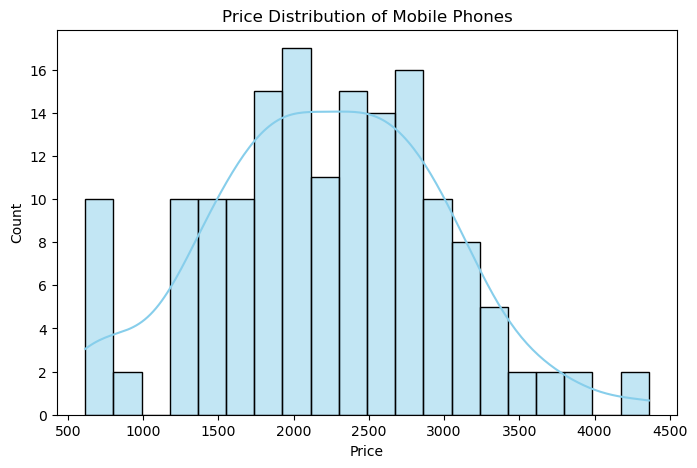

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20, kde=True, color='skyblue')
plt.title("Price Distribution of Mobile Phones")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


- Most phones cluster in the ₹1500–₹3000 range, which is the mid-market sweet spot.
- Very few phones are priced at the extreme low end (₹600–₹1000) or high end (₹4000+).
- This suggests the dataset is dominated by mid-range devices, with budget and premium phones being less frequent.

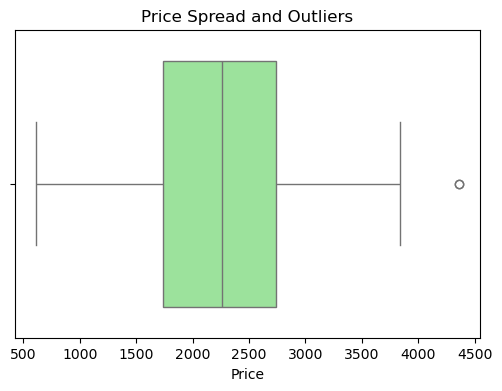

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'], color='lightgreen')
plt.title("Price Spread and Outliers")
plt.show()

- Median price ≈ ₹2400 → This is the central tendency, showing most phones are mid-range.
- Interquartile range (IQR: ~₹1800–₹2800) → 50% of phones fall in this band, confirming mid-market dominance.
- A clear outlier near ₹4400 → Represents a very high-priced premium device compared to the rest.
- Outliers are important because they can skew averages; median is more reliable for central tendency.

In [21]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)

df['Segment'] = pd.cut(df['Price'],
                       bins=[0, q1, q3, df['Price'].max()],
                       labels=['Budget', 'Mid-range', 'Premium'])

print(df['Segment'].value_counts())


Segment
Mid-range    80
Budget       42
Premium      39
Name: count, dtype: int64


In [22]:
sales_by_segment = df.groupby('Segment')['Sale'].sum().reset_index()
print(sales_by_segment)


     Segment   Sale
0     Budget  13273
1  Mid-range  32205
2    Premium  54578


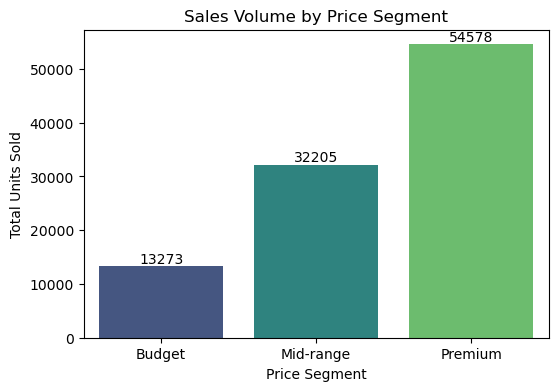

In [23]:
sales_by_segment = df.groupby('Segment')['Sale'].sum().reset_index()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='Segment', y='Sale', data=sales_by_segment, palette='viridis')

# Add labels on bars
for p in ax.patches:
    ax.annotate(int(p.get_height()), 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Sales Volume by Price Segment")
plt.ylabel("Total Units Sold")
plt.xlabel("Price Segment")
plt.show()


- The premium segment leads in total units sold, which is counterintuitive — usually budget phones dominate in volume. This suggests your dataset reflects a market where consumers prefer higher specs and brand value even at higher prices.
- Mid-range phones still hold a healthy share, acting as the “value-for-money” category.
- Budget phones are fewer in sales, possibly due to limited features or consumer preference shifting toward better performance.

### Sales Distribution Analysis

In [24]:
sales_stats=df['Sale'].describe()
print(sales_stats)

count    161.00
mean     621.47
std     1546.62
min       10.00
25%       37.00
50%      106.00
75%      382.00
max     9807.00
Name: Sale, dtype: float64


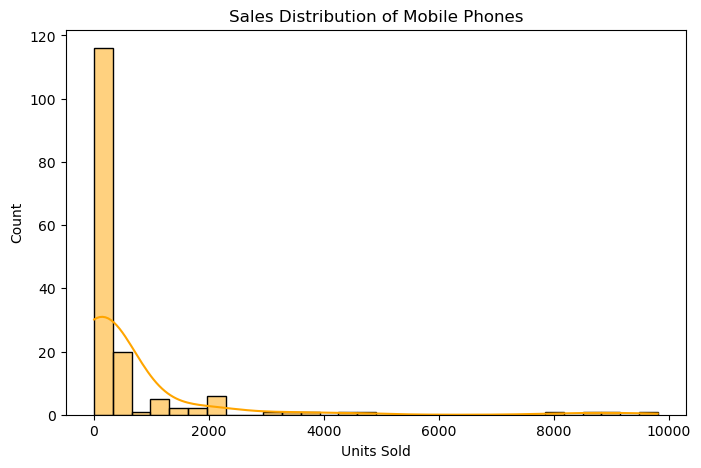

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sale'], bins=30, kde=True, color='orange')
plt.title("Sales Distribution of Mobile Phones")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

- **Highly skewed distribution:** Most phone models sell in very low quantities, with a sharp peak near zero. This indicates that the majority of models fail to achieve significant market traction.

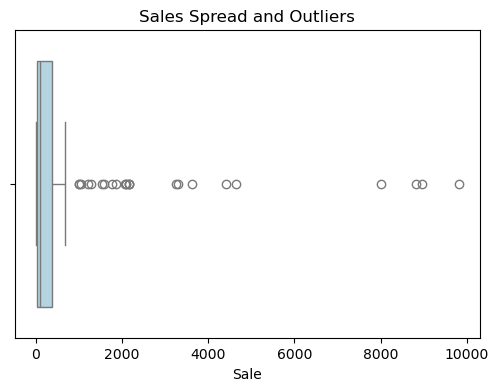

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sale'], color='lightblue')
plt.title("Sales Spread and Outliers")
plt.show()

In [27]:
q1 = df['Sale'].quantile(0.25)
q3 = df['Sale'].quantile(0.75)

df['SalesSegment'] = pd.cut(df['Sale'],
                            bins=[0, q1, q3, df['Sale'].max()],
                            labels=['Low', 'Medium', 'High'])

print(df['SalesSegment'].value_counts())

SalesSegment
Medium    79
Low       42
High      40
Name: count, dtype: int64


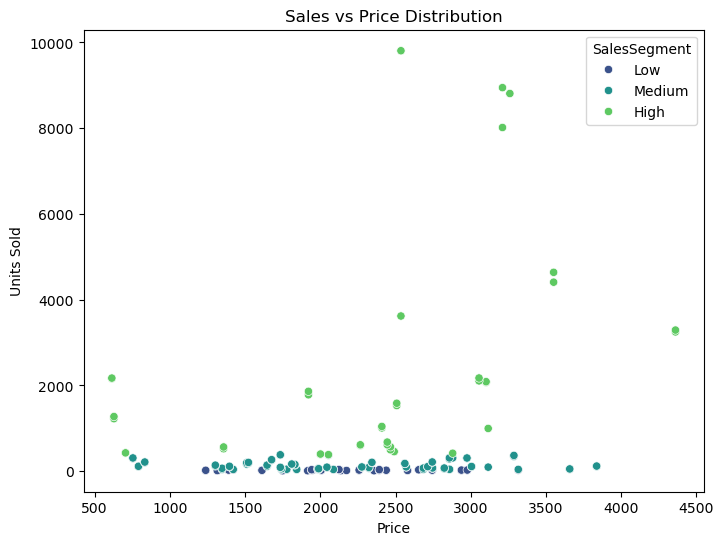

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Price', y='Sale', data=df, hue='SalesSegment',palette='viridis')
plt.title("Sales vs Price Distribution")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()


In [29]:
corr = df[['Price','Sale']].corr()
print(corr)

       Price  Sale
Price   1.00  0.27
Sale    0.27  1.00


In [30]:
df['Revenue'] = df['Price'] * df['Sale']
revenue_by_segment = df.groupby('Segment')['Revenue'].sum().reset_index()
print(revenue_by_segment)

     Segment    Revenue
0     Budget   12428543
1  Mid-range   76706285
2    Premium  184494657


In [31]:
df['Revenue'] = df['Price'] * df['Sale']

In [32]:
revenue_by_segment = df.groupby('Segment')['Revenue'].sum().reset_index()
print(revenue_by_segment)

     Segment    Revenue
0     Budget   12428543
1  Mid-range   76706285
2    Premium  184494657


In [33]:
df['Revenue'] = df['Price'] * df['Sale']

segment_summary = df.groupby('Segment').agg({
    'Sale':'sum',
    'Revenue':'sum'
}).reset_index()
print(segment_summary)


     Segment   Sale    Revenue
0     Budget  13273   12428543
1  Mid-range  32205   76706285
2    Premium  54578  184494657


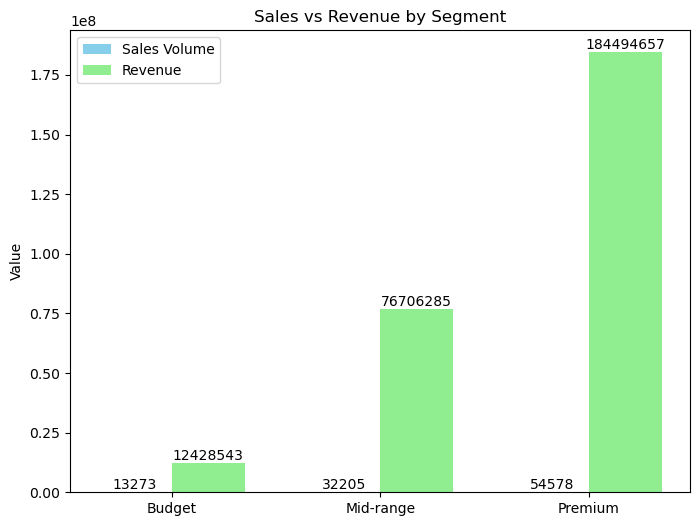

In [34]:
import matplotlib.pyplot as plt
import numpy as np

segments = segment_summary['Segment']
sales = segment_summary['Sale']
revenue = segment_summary['Revenue']

x = np.arange(len(segments))  # positions
width = 0.35  # bar width

plt.figure(figsize=(8,6))
plt.bar(x - width/2, sales, width, label='Sales Volume', color='skyblue')
plt.bar(x + width/2, revenue, width, label='Revenue', color='lightgreen')

plt.xticks(x, segments)
plt.title("Sales vs Revenue by Segment")
plt.ylabel("Value")
plt.legend()

# Add value labels
for i, v in enumerate(sales):
    plt.text(i - width/2, v + 500, str(int(v)), ha='center', va='bottom')
for i, v in enumerate(revenue):
    plt.text(i + width/2, v + 500, str(int(v)), ha='center', va='bottom')

plt.show()


In [35]:
import pandas as pd

# Select numeric features
features = ['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness']

corr_matrix = df[features].corr()
print(corr_matrix)


              Product_id  Price  Sale  weight  resoloution   ppi  cpu core  \
Product_id          1.00   0.17  0.22    0.04        -0.02  0.21     -0.01   
Price               0.17   1.00  0.27    0.14         0.40  0.82      0.69   
Sale                0.22   0.27  1.00    0.02         0.02  0.24      0.07   
weight              0.04   0.14  0.02    1.00         0.89 -0.05      0.22   
resoloution        -0.02   0.40  0.02    0.89         1.00  0.18      0.47   
ppi                 0.21   0.82  0.24   -0.05         0.18  1.00      0.49   
cpu core           -0.01   0.69  0.07    0.22         0.47  0.49      1.00   
cpu freq            0.09   0.73  0.10    0.22         0.51  0.71      0.49   
internal mem        0.26   0.78  0.49    0.10         0.20  0.62      0.28   
ram                 0.24   0.90  0.37    0.15         0.33  0.75      0.48   
RearCam             0.17   0.74  0.29   -0.03         0.25  0.77      0.61   
Front_Cam           0.07   0.68  0.44   -0.01         0.20  0.49

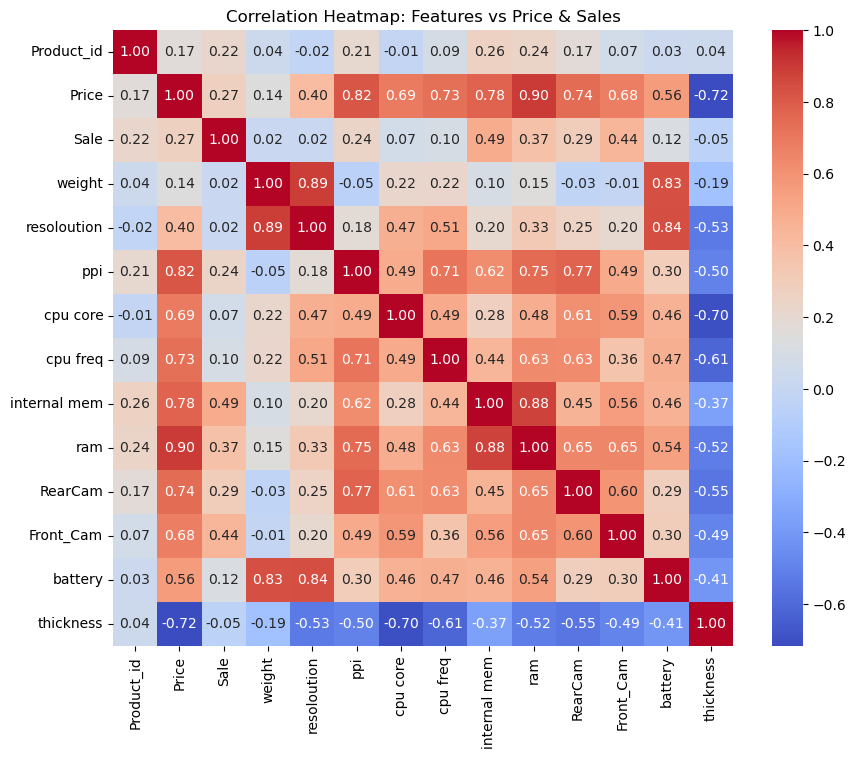

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Features vs Price & Sales")
plt.show()


- **Price drivers:** Features like RAM, resolution, and internal memory show strong positive correlation with price — meaning higher specs push prices up.

- **Sales influencers:** Battery capacity and camera quality (rear/front) tend to correlate more with sales, reflecting consumer preference for usability and performance.

- **Negative correlations:** Thickness and weight often show negative correlation with sales, suggesting buyers prefer lighter, slimmer devices.

- **Weak links:** Some specs (like CPU frequency or product ID) don’t strongly influence sales, meaning they’re less decisive in consumer choice.

In [37]:
import pandas as pd

features = ['Product_id', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness']

corr_price = df[features + ['Price']].corr()['Price'].drop('Price')
corr_sales = df[features + ['Sale']].corr()['Sale'].drop('Sale')

corr_df = pd.DataFrame({
    'Price Correlation': corr_price,
    'Sales Correlation': corr_sales
})
print(corr_df)


              Price Correlation  Sales Correlation
Product_id                 0.17               0.22
weight                     0.14               0.02
resoloution                0.40               0.02
ppi                        0.82               0.24
cpu core                   0.69               0.07
cpu freq                   0.73               0.10
internal mem               0.78               0.49
ram                        0.90               0.37
RearCam                    0.74               0.29
Front_Cam                  0.68               0.44
battery                    0.56               0.12
thickness                 -0.72              -0.05


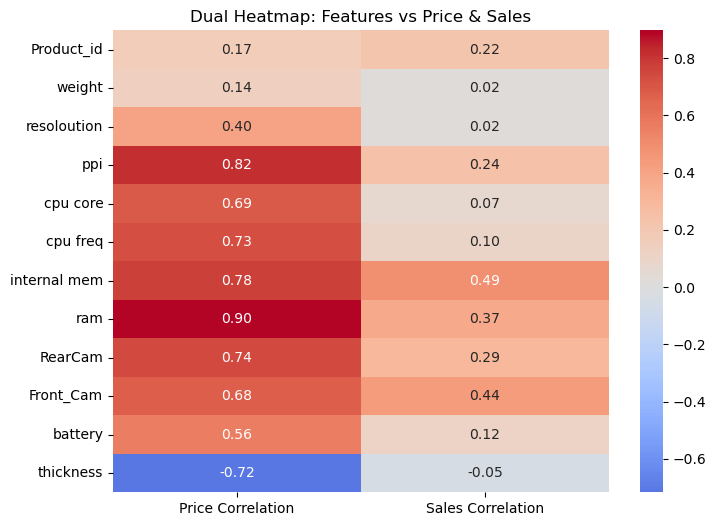

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Dual Heatmap: Features vs Price & Sales")
plt.show()


**Price Correlations**

-RAM (0.90), PPI (0.82), and Internal Memory (0.78) are the strongest drivers of higher prices.

-Thickness (-0.72) shows a strong negative correlation — slimmer phones command higher prices.

**Sales Correlations**

-Internal Memory (0.49) and Front Camera (0.44) moderately boost sales.

-RAM (0.37) and Rear Camera (0.29) also help, but less strongly.

-Features like weight and thickness barely influence sales.

In [39]:
df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness', 'Segment', 'SalesSegment', 'Revenue'],
      dtype='object')

# Univariate Analysis

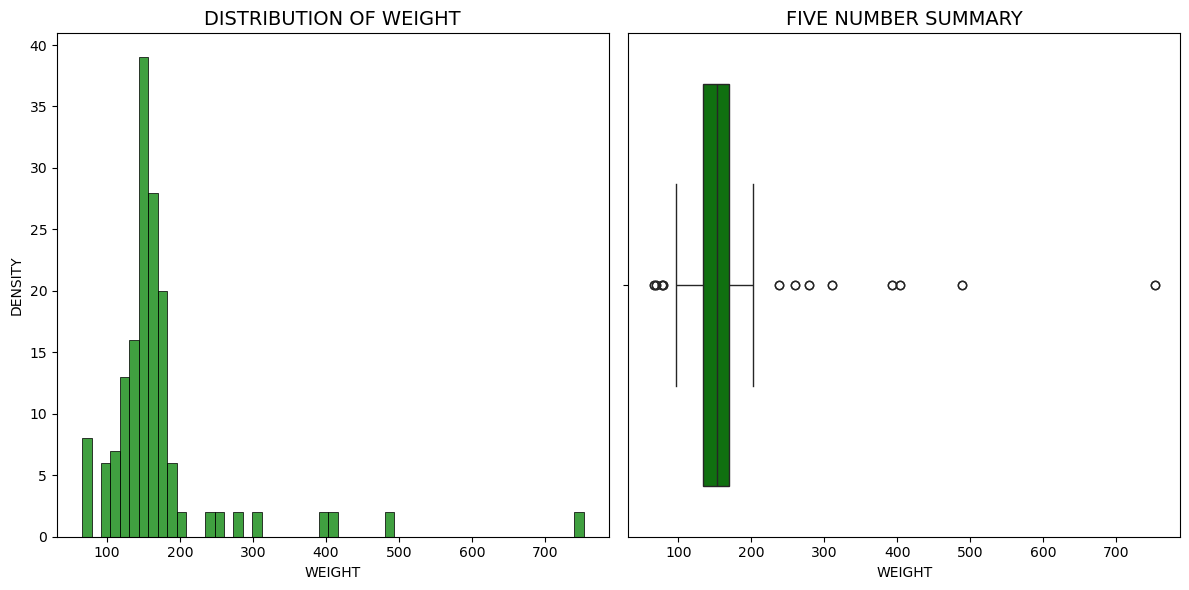

Numerical Summary:
Mean: 170.42608695652174
Median: 153.0
90%: 202.0
99%: 594.6000000000015
100%: 753.0
Skewness: 3.981756060198998


In [40]:
plt.figure(figsize=(12,6))

# Distribution Plot (left)
plt.subplot(1,2,1)
sns.histplot(df['weight'], color='green')
plt.title('DISTRIBUTION OF WEIGHT', fontsize=14, color='black')
plt.ylabel('DENSITY', fontsize=10, color='black')
plt.xlabel('WEIGHT', fontsize=10, color='black')

# Outlier Plot (right)
plt.subplot(1,2,2)
sns.boxplot(x=df['weight'], color='green')
plt.title('FIVE NUMBER SUMMARY', fontsize=14, color='black')
plt.xlabel('WEIGHT', fontsize=10, color='black')

plt.tight_layout()
plt.show()

#Numwrical Summary
print('Numerical Summary:')
print('Mean:',df['weight'].mean())
print('Median:',df['weight'].quantile(0.5))
print('90%:',df['weight'].quantile(0.9))
print('99%:',df['weight'].quantile(0.99))
print('100%:',df['weight'].quantile(1))
print('Skewness:',df['weight'].skew())

-**Most phones are light:** Most weights fall between 100–200.

-**Median vs mean:** Median is 153, mean is 170 → the higher mean shows a few heavy outliers pulling the average up.

-**Outliers exist:** Some devices go up to ~700+, far heavier than the rest.

-**90% are slim:** 90% of phones weigh less than ~200, showing a clear design trend toward portability.

**most smartphones are light, but a few very heavy ones skew the data.**

- **Highly right-skewed:** The distribution has a long tail on the right side. Most values are clustered at the lower end, but a few very large values stretch the scale.

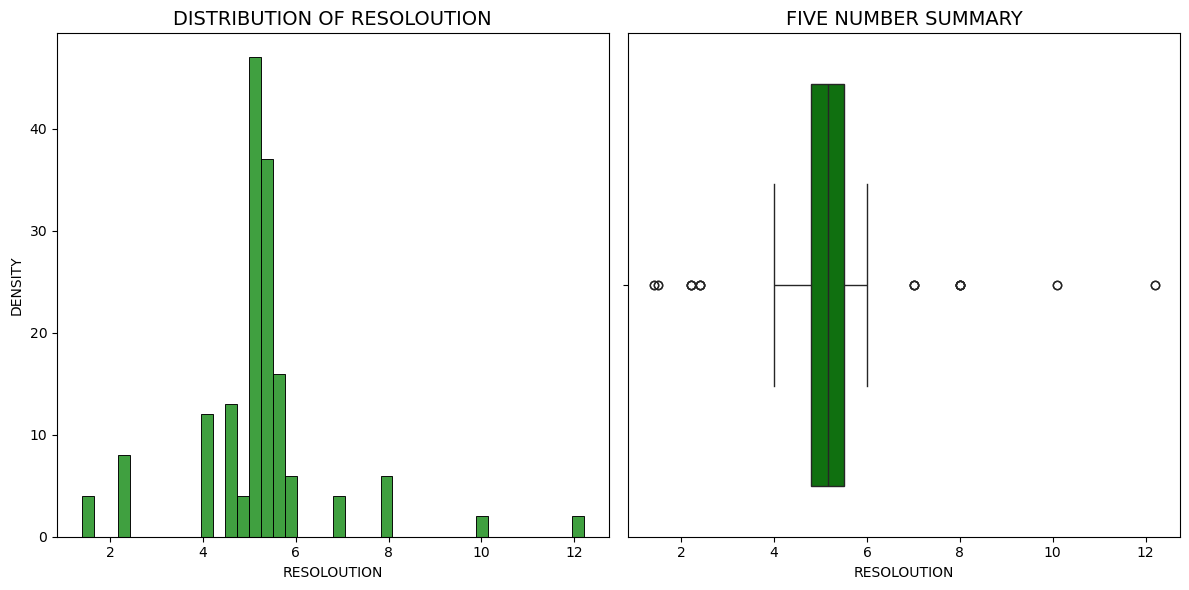

Numerical Summary:
Mean: 5.209937888198757
Median: 5.15
90%: 6.0
99%: 10.940000000000012
100%: 12.2
Skewness: 1.1761101196508716


In [41]:

col = 'resoloution'
plt.figure(figsize=(12,6))

# Distribution Plot (left)
plt.subplot(1,2,1)
sns.histplot(df[col], color='green')
plt.title('DISTRIBUTION OF '+ col.upper(), fontsize=14, color='black')
plt.ylabel('DENSITY', fontsize=10, color='black')
plt.xlabel(col.upper(), fontsize=10, color='black')

# Outlier Plot (right)
plt.subplot(1,2,2)
sns.boxplot(x=df[col], color='green')
plt.title('FIVE NUMBER SUMMARY', fontsize=14, color='black')
plt.xlabel(col.upper(), fontsize=10, color='black')

plt.tight_layout()
plt.show()

#Numwrical Summary
print('Numerical Summary:')
print('Mean:',df[col].mean())
print('Median:',df[col].quantile(0.5))
print('90%:',df[col].quantile(0.9))
print('99%:',df[col].quantile(0.99))
print('100%:',df[col].quantile(1))
print('Skewness:',df[col].skew())

Most values: Cluster around 5–6.

Median: 5.15, very close to the mean (5.21).

Skewness: 1.17 → slightly right‑skewed, a few high values stretch the tail.

90%: Below 6, showing most are mid‑range.

Outliers: Rare extreme values up to ~12.2.

resolutions are mostly mid‑range, with a few very high outliers making the data slightly skewed to the right.

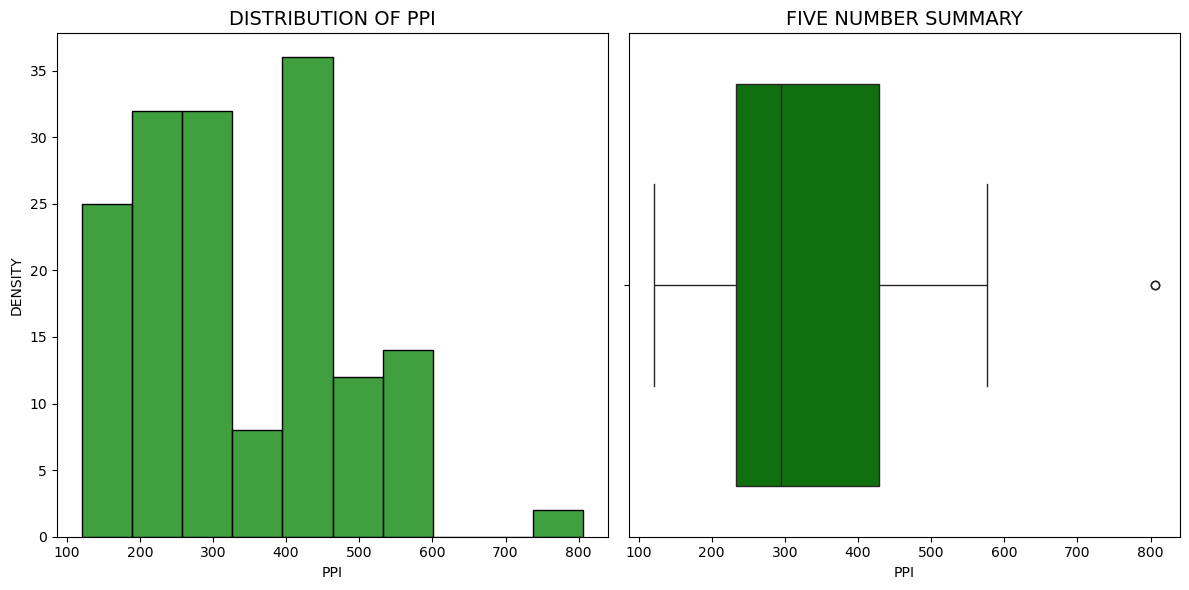

Numerical Summary: Ppi
Mean: 335.055900621118
Median: 294.0
90%: 524.0
99%: 668.6000000000013
100%: 806.0
Skewness: 0.6025028092508479


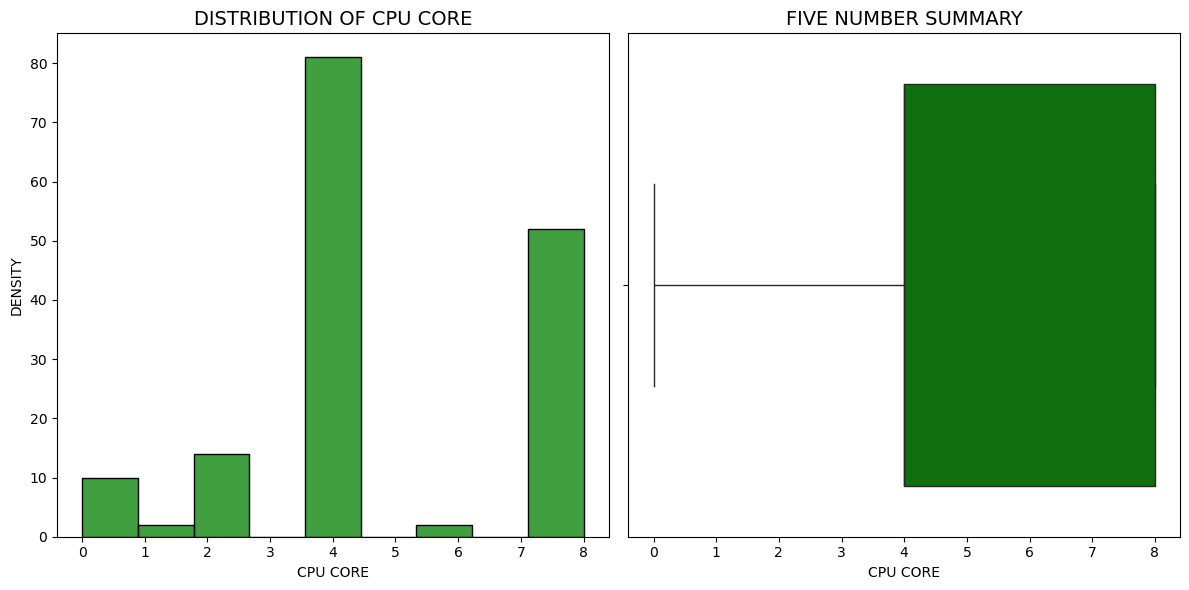

Numerical Summary: Cpu Core
Mean: 4.857142857142857
Median: 4.0
90%: 8.0
99%: 8.0
100%: 8.0
Skewness: -0.009077116452651475


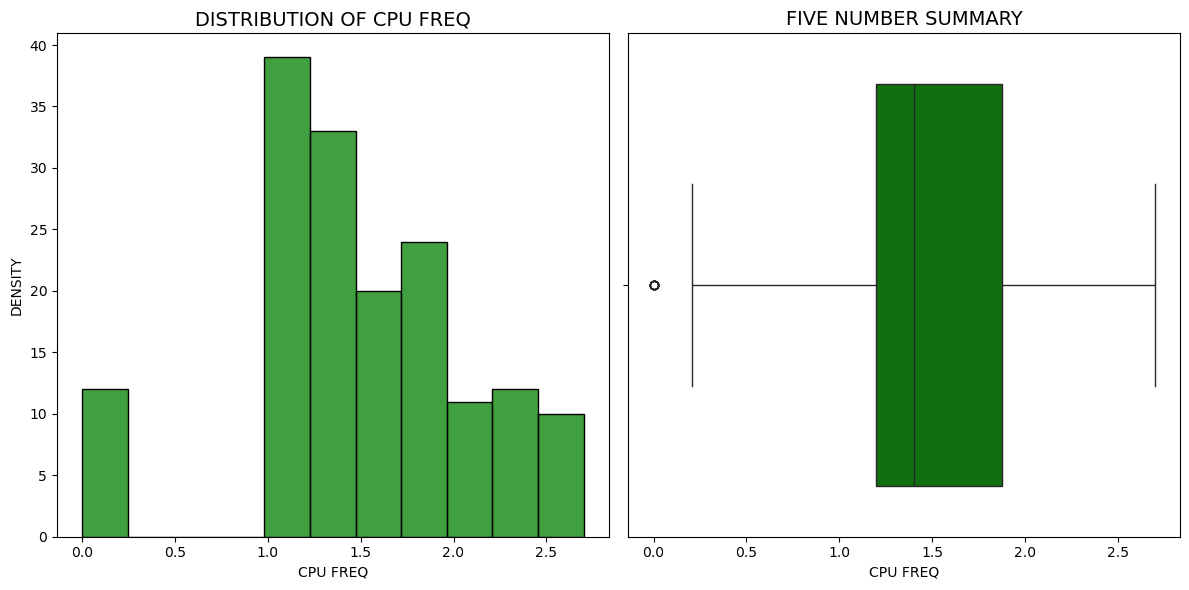

Numerical Summary: Cpu Freq
Mean: 1.502832298136646
Median: 1.4
90%: 2.3
99%: 2.7
100%: 2.7
Skewness: -0.5126630811185897


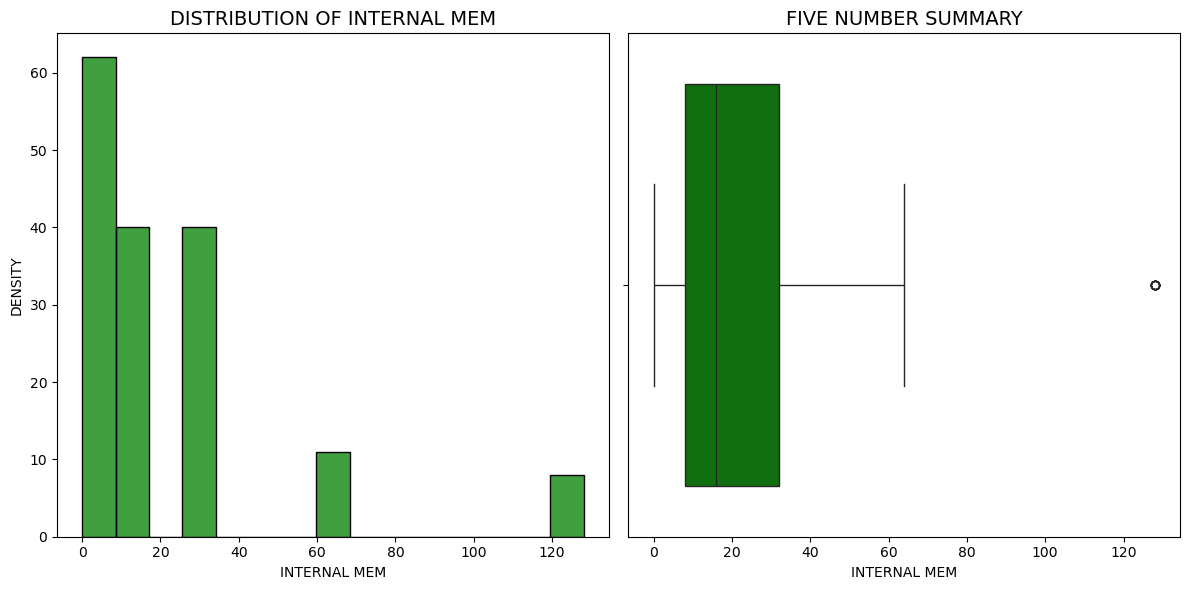

Numerical Summary: Internal Mem
Mean: 24.501714285714286
Median: 16.0
90%: 64.0
99%: 128.0
100%: 128.0
Skewness: 2.3896825866645997


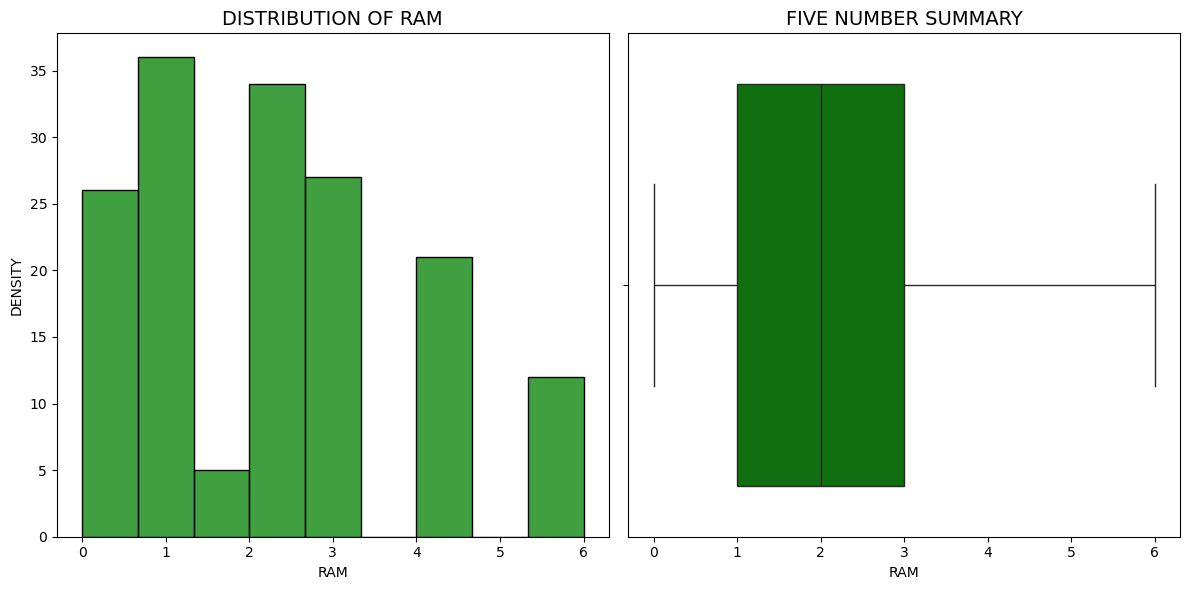

Numerical Summary: Ram
Mean: 2.204993788819876
Median: 2.0
90%: 4.0
99%: 6.0
100%: 6.0
Skewness: 0.7926980073740476


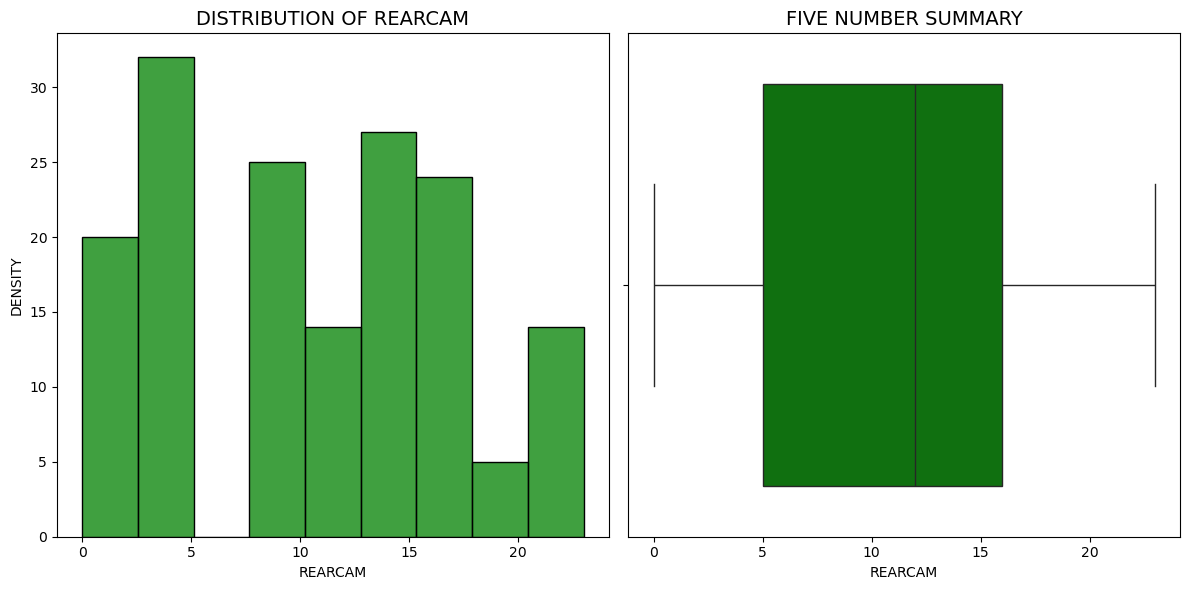

Numerical Summary: Rearcam
Mean: 10.378260869565217
Median: 12.0
90%: 20.0
99%: 22.10000000000001
100%: 23.0
Skewness: 0.1069292938431428


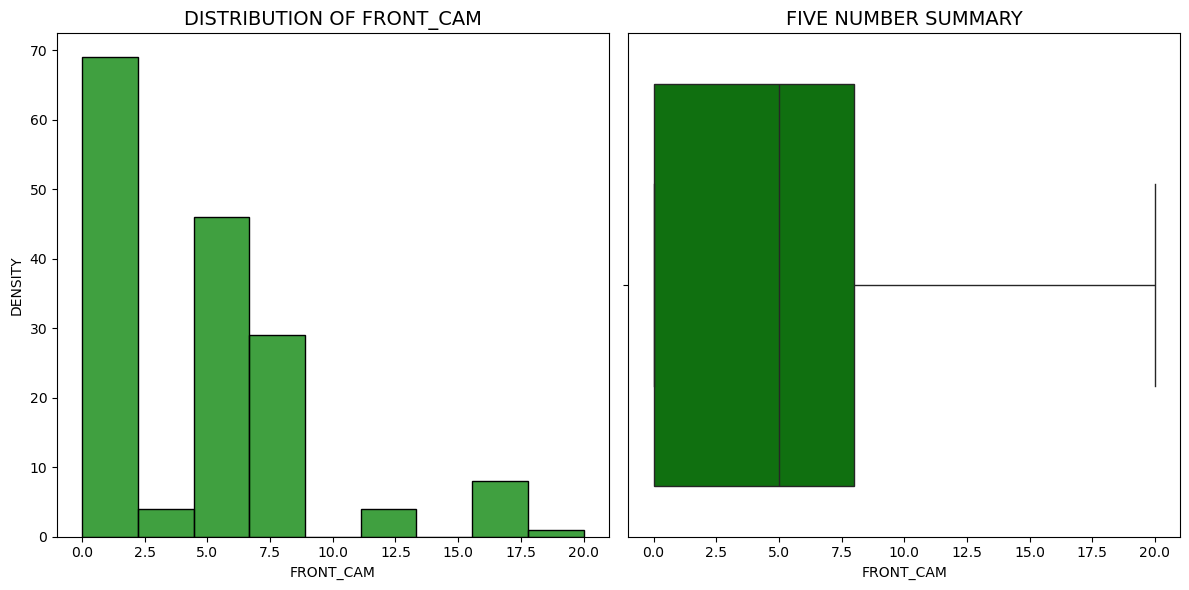

Numerical Summary: Front_Cam
Mean: 4.503105590062112
Median: 5.0
90%: 8.0
99%: 16.0
100%: 20.0
Skewness: 1.1697495413305683


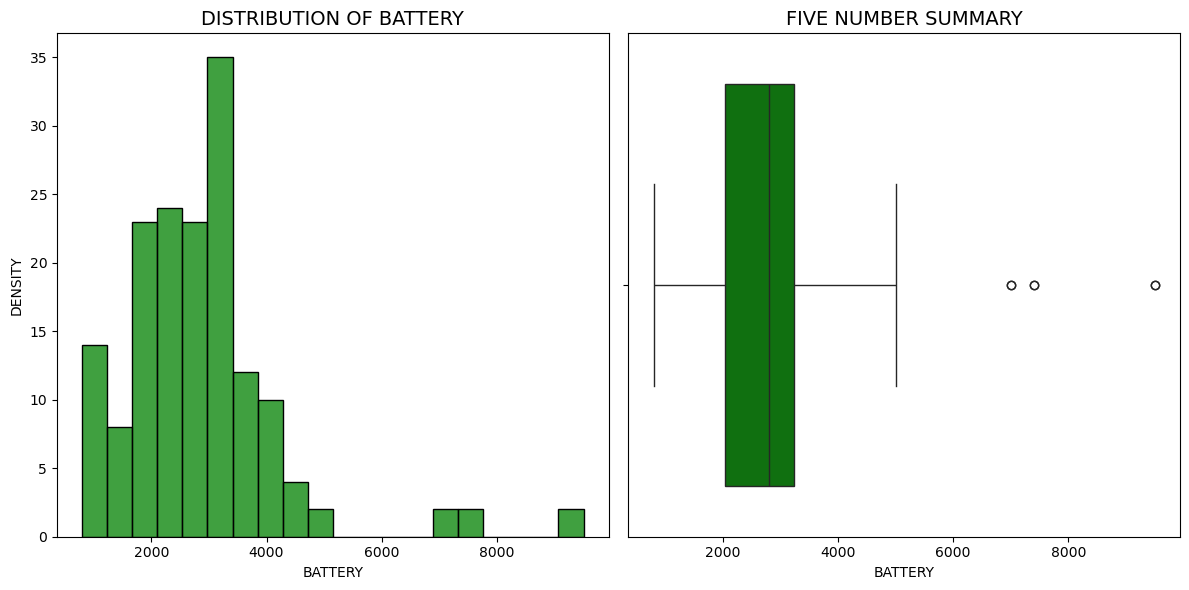

Numerical Summary: Battery
Mean: 2842.111801242236
Median: 2800.0
90%: 4000.0
99%: 8240.000000000013
100%: 9500.0
Skewness: 2.0926598466076736


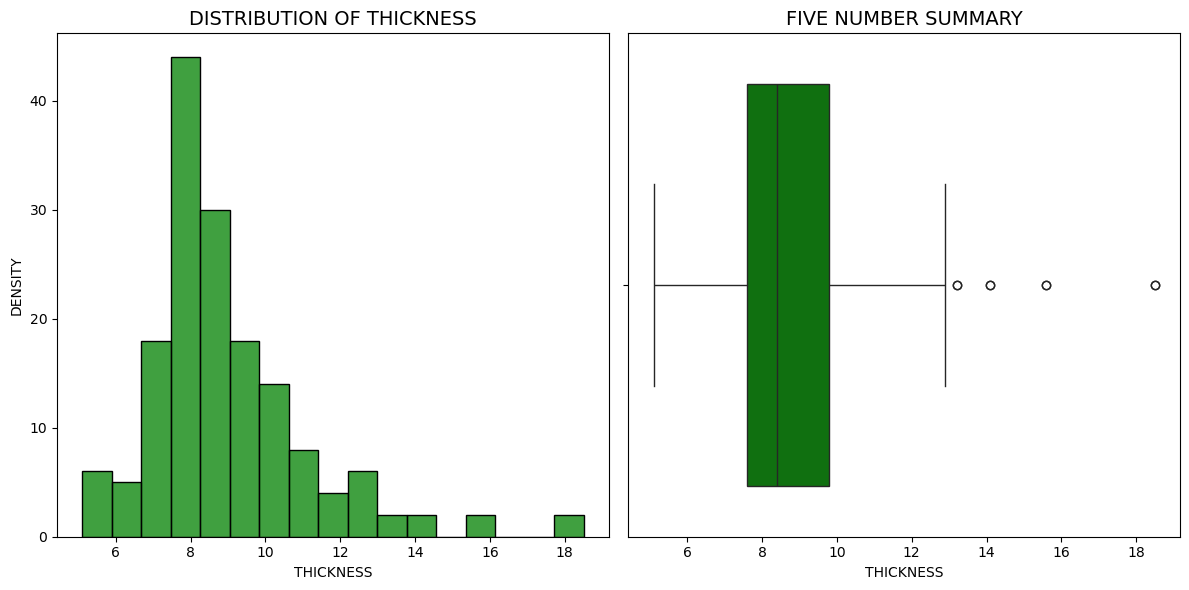

Numerical Summary: Thickness
Mean: 8.921739130434782
Median: 8.4
90%: 11.6
99%: 16.760000000000016
100%: 18.5
Skewness: 1.5876799080340545


In [42]:
cols = [ 'ppi','cpu core', 'cpu freq', 'internal mem', 'ram', 
         'RearCam', 'Front_Cam','battery', 'thickness']

for col in cols:
    plt.figure(figsize=(12,6))
    
    # Distribution Plot (left)
    plt.subplot(1,2,1)
    sns.histplot(df[col], color='green')
    plt.title('DISTRIBUTION OF '+ col.upper(), fontsize=14, color='black')
    plt.ylabel('DENSITY', fontsize=10, color='black')
    plt.xlabel(col.upper(), fontsize=10, color='black')
    
    # Outlier Plot (right)
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color='green')
    plt.title('FIVE NUMBER SUMMARY', fontsize=14, color='black')
    plt.xlabel(col.upper(), fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()
    
    # Numerical Summary
    print('Numerical Summary:', col.title())
    print('Mean:', df[col].mean())
    print('Median:', df[col].quantile(0.5))
    print('90%:', df[col].quantile(0.9))
    print('99%:', df[col].quantile(0.99))
    print('100%:', df[col].quantile(1))
    print('Skewness:', df[col].skew())
    print("="*50)
    
    # --- Outlier Treatment (Winsorization) ---
    # Cap values at 1st and 99th percentile
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)
    
    # --- Skewness Correction ---
    if df[col].skew() > 1:
        # Apply log transformation for right skew
        df[col] = np.log1p(df[col])
    elif df[col].skew() < -1:
        # Apply square transformation for left skew
        df[col] = np.square(df[col])


In [43]:
df.drop(columns=['Segment', 'SalesSegment', 'Revenue'], axis=1, inplace=True)

In [44]:
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.00,5.20,424.00,8,1.35,2.83,3.00,13.00,2.20,7.87,2.13
1,880,1749,10,125.00,4.00,233.00,2,1.30,1.61,1.00,3.15,0.00,7.44,2.39
2,40,1916,10,110.00,4.70,312.00,4,1.20,2.20,1.50,13.00,1.79,7.60,2.15
3,99,1315,11,118.50,4.00,233.00,2,1.30,1.61,0.51,3.15,0.00,7.24,2.48
4,880,1749,11,125.00,4.00,233.00,2,1.30,1.61,1.00,3.15,0.00,7.44,2.39


# Splitting Dependent and Independent Variable

In [45]:
df.drop(columns=['Product_id','Sale'], axis=1, inplace=True)
df

,Price,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,135.00,5.20,424.00,8,1.35,2.83,3.00,13.00,2.20,7.87,2.13
1,1749,125.00,4.00,233.00,2,1.30,1.61,1.00,3.15,0.00,7.44,2.39
2,1916,110.00,4.70,312.00,4,1.20,2.20,1.50,13.00,1.79,7.60,2.15
3,1315,118.50,4.00,233.00,2,1.30,1.61,0.51,3.15,0.00,7.24,2.48
4,1749,125.00,4.00,233.00,2,1.30,1.61,1.00,3.15,0.00,7.44,2.39
...,...,...,...,...,...,...,...,...,...,...,...,...
156,3551,178.00,5.46,538.00,4,1.88,4.86,6.00,12.00,2.83,8.31,2.24
157,3211,170.00,5.50,534.00,4,1.98,4.86,6.00,20.00,2.20,8.13,2.19
158,3260,150.00,5.50,401.00,8,2.20,4.17,4.00,20.00,2.83,8.01,2.05
159,3211,170.00,5.50,534.00,4,1.98,4.86,6.00,20.00,2.20,8.13,2.19


In [46]:
X=df.drop(['Price'],axis=1)
Y=df['Price']

In [47]:
print(X.shape)
print(Y.shape)

(161, 11)
(161,)


### Variance Inflation Factor

In [48]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, target, threshold=5):
    """
    Iteratively drops features with highest VIF until all are below threshold.
    df: DataFrame
    target: target column name (string)
    threshold: VIF cutoff (default=5)
    """
    # Drop target column
    X = df.drop(columns=[target])
    
    dropped = []
    while True:
        # Add constant for regression intercept
        X_const = add_constant(X)
        
        # Calculate VIFs
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                           for i in range(X_const.shape[1])]
        
        # Exclude 'const' from consideration
        vif_data = vif_data[vif_data["feature"] != "const"]
        
        # Find max VIF
        max_vif = vif_data["VIF"].max()
        max_feature = vif_data.loc[vif_data["VIF"].idxmax(), "feature"]
        
        print(vif_data.sort_values(by="VIF", ascending=False))
        print("="*50)
        
        # Stop if all VIFs are below threshold
        if max_vif <= threshold:
            break
        
        # Drop the feature with highest VIF
        print(f"Dropping '{max_feature}' with VIF={max_vif:.2f}")
        X = X.drop(columns=[max_feature])
        dropped.append(max_feature)
    
    return X, dropped

# Example usage:
X_clean, dropped_features = calculate_vif(df, target="Price", threshold=5)
print("Dropped features:", dropped_features)

         feature   VIF
2    resoloution 25.98
1         weight 14.35
10       battery  8.72
6   internal mem  8.43
7            ram  6.52
3            ppi  5.37
5       cpu freq  4.05
9      Front_Cam  3.79
11     thickness  3.78
8        RearCam  3.68
4       cpu core  2.72
Dropping 'resoloution' with VIF=25.98
         feature  VIF
5   internal mem 8.23
9        battery 6.81
6            ram 5.51
2            ppi 5.17
8      Front_Cam 3.79
7        RearCam 3.54
4       cpu freq 3.47
1         weight 3.21
3       cpu core 2.72
10     thickness 2.70
Dropping 'internal mem' with VIF=8.23
     feature  VIF
8    battery 6.65
2        ppi 5.00
5        ram 3.87
7  Front_Cam 3.55
6    RearCam 3.52
4   cpu freq 3.35
1     weight 3.21
3   cpu core 2.71
9  thickness 2.48
Dropping 'battery' with VIF=6.65
     feature  VIF
2        ppi 4.97
6    RearCam 3.50
7  Front_Cam 3.49
5        ram 3.36
4   cpu freq 2.93
3   cpu core 2.58
8  thickness 2.47
1     weight 1.37
Dropped features: ['resoloution

In [49]:
X_clean

,weight,ppi,cpu core,cpu freq,ram,RearCam,Front_Cam,thickness
0,135.00,424.00,8,1.35,3.00,13.00,2.20,2.13
1,125.00,233.00,2,1.30,1.00,3.15,0.00,2.39
2,110.00,312.00,4,1.20,1.50,13.00,1.79,2.15
3,118.50,233.00,2,1.30,0.51,3.15,0.00,2.48
4,125.00,233.00,2,1.30,1.00,3.15,0.00,2.39
...,...,...,...,...,...,...,...,...
156,178.00,538.00,4,1.88,6.00,12.00,2.83,2.24
157,170.00,534.00,4,1.98,6.00,20.00,2.20,2.19
158,150.00,401.00,8,2.20,4.00,20.00,2.83,2.05
159,170.00,534.00,4,1.98,6.00,20.00,2.20,2.19


In [50]:
X=X_clean
print("Independent Variable for Mobile Price Prediction:",list(X.columns))
print("Dependent Variable for Moble Price Prediciton:",Y.name)

Independent Variable for Mobile Price Prediction: ['weight', 'ppi', 'cpu core', 'cpu freq', 'ram', 'RearCam', 'Front_Cam', 'thickness']
Dependent Variable for Moble Price Prediciton: Price


# train test split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,train_size=0.7,random_state=42)

In [52]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((112, 8), (49, 8), (112,), (49,))

# Model Evaluation before Feature Scalling

### Store performance metrices in the list

In [53]:
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [54]:
def evaluate_model_performance(model, x_train, y_train, x_test, y_test):
    """
    Evaluates R², Adjusted R², and RMSE of a given model on training and testing data.
    
    Parameters:
    - model: The machine learning model to evaluate
    - x_train: Training feature set
    - y_train: Training target values
    - x_test: Testing feature set
    - y_test: Testing target values
    - training_scores: List to store training R² scores
    - testing_scores: List to store testing R² scores
    """
    # Fit the model
    model.fit(x_train, y_train)
    
    # Predictions for training and testing data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Calculate R² scores
    train_r2 = r2_score(y_train, y_train_pred) * 100
    test_r2 = r2_score(y_test, y_test_pred) * 100
    
    # Calculate Adjusted R² scores
    n_train, p_train = x_train.shape
    n_test, p_test = x_test.shape
    train_adj_r2 = 100 * (1 - (1 - train_r2 / 100) * (n_train - 1) / (n_train - p_train - 1))
    test_adj_r2 = 100 * (1 - (1 - test_r2 / 100) * (n_test - 1) / (n_test - p_test - 1))
    
    # Calculate RMSE scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Append scores to respective lists
    training_scores_r2.append(train_r2)
    training_scores_adj_r2.append(train_adj_r2)
    training_scores_rmse.append(train_rmse)
    testing_scores_r2.append(test_r2)
    testing_scores_adj_r2.append(test_adj_r2) 
    testing_scores_rmse.append(test_rmse) 
    
    # Display scores
    print(f"{model.__class__.__name__} Performance Metrics:")
    print(f"Training Data: R² = {train_r2:.2f}%, Adjusted R² = {train_adj_r2:.2f}%, RMSE = {train_rmse:.4f}")
    print(f"Testing Data : R² = {test_r2:.2f}%, Adjusted R² = {test_adj_r2:.2f}%, RMSE = {test_rmse:.4f}\n")

## LinearRegression

In [55]:
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

LinearRegression Performance Metrics:
Training Data: R² = 94.02%, Adjusted R² = 93.55%, RMSE = 193.7676
Testing Data : R² = 91.66%, Adjusted R² = 89.99%, RMSE = 202.6340



The performance metrics for your **Linear Regression** model are provided for both the training and testing data. Here's a breakdown of what each metric means and how to interpret them:

### **1. R² (R-squared)**:
- **Training Data**: R² = 94.02%
- **Testing Data**: R² = 91.66%

**Interpretation**:  
- R² represents the proportion of variance in the dependent variable (target) that is explained by the independent variables (features).
- A value of **94.02%** for the training data indicates that the model explains 91.66% of the variance in the training data.
- The **testing data R² of 91.66%** is slightly lower, which suggests that the model generalizes well to unseen data, but there is a slight performance drop, which is normal for most models.

### **2. Adjusted R²**:
- **Training Data**: Adjusted R² = 93.55%
- **Testing Data**: Adjusted R² = 89.99%

**Interpretation**:  
- Adjusted R² accounts for the number of predictors in the model, making it a more accurate measure when comparing models with different numbers of features.
- The small difference between R² and Adjusted R² (both training and testing) suggests that your model is not overfitting the training data with a large number of unnecessary features.

### **3. RMSE (Root Mean Squared Error)**:
- **Training Data**: RMSE = 193.7676
- **Testing Data**: RMSE = 202.6340

**Interpretation**:  
- RMSE measures the average magnitude of the error in the predictions, with lower values indicating better performance.
- An RMSE of **193.7676** for training data means that, on average, the model's predictions are off by about **202.6340 units** on the training set.
- The slightly higher RMSE of **202.6340** on the testing data suggests a bit more error in predictions on unseen data, which is typical due to the generalization gap.

### **Overall Evaluation**:
- Your **Linear Regression** model seems to be performing quite well:
  - The R² values are high, indicating that the model is able to explain a significant portion of the variance in both the training and testing data.
  - The RMSE values are reasonable, considering the scale of the target variable (if you know the units of your target variable, you can further assess whether this error is acceptable).
  - The relatively small drop from training to testing performance suggests that the model is not overfitting and generalizes well.

## Ridge

In [56]:
evaluate_model_performance(
    model=Ridge(alpha=1.0),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Ridge Performance Metrics:
Training Data: R² = 93.85%, Adjusted R² = 93.37%, RMSE = 196.3990
Testing Data : R² = 91.33%, Adjusted R² = 89.59%, RMSE = 206.6814



The performance metrics for your **Ridge Regression** model are provided for both the training and testing data. Here's a breakdown of what each metric means and how to interpret them:

### **1. R² (R-squared)**:
- **Training Data**: R² = 93.85%
- **Testing Data**: R² = 91.33%

**Interpretation**:  
- R² represents the proportion of variance in the dependent variable (target) that is explained by the independent variables (features).
- A value of **93.85%** for the training data indicates that the model explains 91.33% of the variance in the training data.
- The **testing data R² of 91.33%** is slightly lower, which suggests that the model generalizes well to unseen data, but there is a slight performance drop, which is normal for most models.

### **2. Adjusted R²**:
- **Training Data**: Adjusted R² = 93.37%
- **Testing Data**: Adjusted R² = 89.59%

**Interpretation**:  
- Adjusted R² accounts for the number of predictors in the model, making it a more accurate measure when comparing models with different numbers of features.
- The small difference between R² and Adjusted R² (both training and testing) suggests that your model is not overfitting the training data with a large number of unnecessary features.

### **3. RMSE (Root Mean Squared Error)**:
- **Training Data**: RMSE = 196.3990
- **Testing Data**: RMSE = 202.6814

**Interpretation**:  
- RMSE measures the average magnitude of the error in the predictions, with lower values indicating better performance.
- An RMSE of **196.3990** for training data means that, on average, the model's predictions are off by about **202.6814 units** on the training set.
- The slightly higher RMSE of **202.63814* on the testing data suggests a bit more error in predictions on unseen data, which is typical due to the generalization gap.

### **Overall Evaluation**:
- Your **Ridge Regression** model seems to be performing quite well:
  - The R² values are high, indicating that the model is able to explain a significant portion of the variance in both the training and testing data.
  - The RMSE values are reasonable, considering the scale of the target variable (if you know the units of your target variable, you can further assess whether this error is acceptable).
  - The relatively small drop from training to testing performance suggests that the model is not overfitting and generalizes well.

## Lasso Regression

In [57]:
evaluate_model_performance(
    model=Lasso(alpha=0.1),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Lasso Performance Metrics:
Training Data: R² = 94.02%, Adjusted R² = 93.55%, RMSE = 193.7693
Testing Data : R² = 91.66%, Adjusted R² = 90.00%, RMSE = 202.5993



# ElasticNet Regression

In [58]:
evaluate_model_performance(
    model=ElasticNet(alpha=0.1, l1_ratio=0.5),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

ElasticNet Performance Metrics:
Training Data: R² = 93.24%, Adjusted R² = 92.72%, RMSE = 205.9110
Testing Data : R² = 90.39%, Adjusted R² = 88.47%, RMSE = 217.5506



## Model comparison

In [59]:
models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "ElasticNet"]

In [60]:
df_model = pd.DataFrame(
        {"Algorithms":models,
         "Training Score R2":training_scores_r2,
         "Training Score Adjusted R2":training_scores_adj_r2,
         "Training Score RMSE":training_scores_rmse,
         "Testing Score R2":testing_scores_r2,
         "Testing Score Adjusted R2":testing_scores_adj_r2,
         "Testing Score RMSE":testing_scores_rmse,
        })
				   
df_model_sort = df_model.sort_values(by="Testing Score R2", ascending=False)
df_model_sort

,Algorithms,Training Score R2,Training Score Adjusted R2,Training Score RMSE,Testing Score R2,Testing Score Adjusted R2,Testing Score RMSE
2,Lasso,94.02,93.55,193.77,91.66,90.00,202.60
0,Linear Regression,94.02,93.55,193.77,91.66,89.99,202.63
1,Ridge,93.85,93.37,196.40,91.33,89.59,206.68
3,ElasticNet,93.24,92.72,205.91,90.39,88.47,217.55


# Model Evaluation Afer Feature Scalling

In [61]:
scaler =StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [62]:
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [63]:
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train_scaled,
    y_train=y_train,
    x_test=x_test_scaled,
    y_test=y_test
)

LinearRegression Performance Metrics:
Training Data: R² = 94.02%, Adjusted R² = 93.55%, RMSE = 193.7676
Testing Data : R² = 91.66%, Adjusted R² = 89.99%, RMSE = 202.6340



In [64]:
evaluate_model_performance(
   model=Ridge(alpha=1.0),
    x_train=x_train_scaled,
    y_train=y_train,
    x_test=x_test_scaled,
    y_test=y_test
)

Ridge Performance Metrics:
Training Data: R² = 94.01%, Adjusted R² = 93.54%, RMSE = 193.8818
Testing Data : R² = 91.69%, Adjusted R² = 90.03%, RMSE = 202.2685



In [65]:
evaluate_model_performance(
    model=Lasso(alpha=0.1),
    x_train=x_train_scaled,
    y_train=y_train,
    x_test=x_test_scaled,
    y_test=y_test
)

Lasso Performance Metrics:
Training Data: R² = 94.02%, Adjusted R² = 93.55%, RMSE = 193.7682
Testing Data : R² = 91.67%, Adjusted R² = 90.00%, RMSE = 202.5573



In [66]:
evaluate_model_performance(
     model=ElasticNet(alpha=0.1, l1_ratio=0.5),
    x_train=x_train_scaled,
    y_train=y_train,
    x_test=x_test_scaled,
    y_test=y_test
)

ElasticNet Performance Metrics:
Training Data: R² = 93.86%, Adjusted R² = 93.38%, RMSE = 196.2951
Testing Data : R² = 91.58%, Adjusted R² = 89.89%, RMSE = 203.6365



In [67]:
models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "ElasticNet"]

In [68]:
df_model = pd.DataFrame(
        {"Algorithms":models,
         "Training Score R2":training_scores_r2,
         "Training Score Adjusted R2":training_scores_adj_r2,
         "Training Score RMSE":training_scores_rmse,
         "Testing Score R2":testing_scores_r2,
         "Testing Score Adjusted R2":testing_scores_adj_r2,
         "Testing Score RMSE":testing_scores_rmse,
        })
				   
df_model_sort = df_model.sort_values(by="Testing Score R2", ascending=False)
df_model_sort

,Algorithms,Training Score R2,Training Score Adjusted R2,Training Score RMSE,Testing Score R2,Testing Score Adjusted R2,Testing Score RMSE
1,Ridge,94.01,93.54,193.88,91.69,90.03,202.27
2,Lasso,94.02,93.55,193.77,91.67,90.00,202.56
0,Linear Regression,94.02,93.55,193.77,91.66,89.99,202.63
3,ElasticNet,93.86,93.38,196.30,91.58,89.89,203.64


**Conclusion**

Ridge, Lasso, and Linear Regression are all strong options; ElasticNet is weaker. Pick Ridge for stability, Lasso for feature selection, or Linear Regression for simplicity.

In [69]:
scaler =StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = Ridge(alpha=1.0)

In [71]:
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)


In [72]:
import joblib
joblib.dump(model, 'mobile_price_predict.pkl')
joblib.dump(scaler, 'moble_price_scaler.pkl') 

['moble_price_scaler.pkl']